<>:69: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
<>:69: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_23880\3293037536.py:69: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
  plt.title("Espacio fase de $\dot{x}=y$, $\dot{y}=x\cos(y)$")


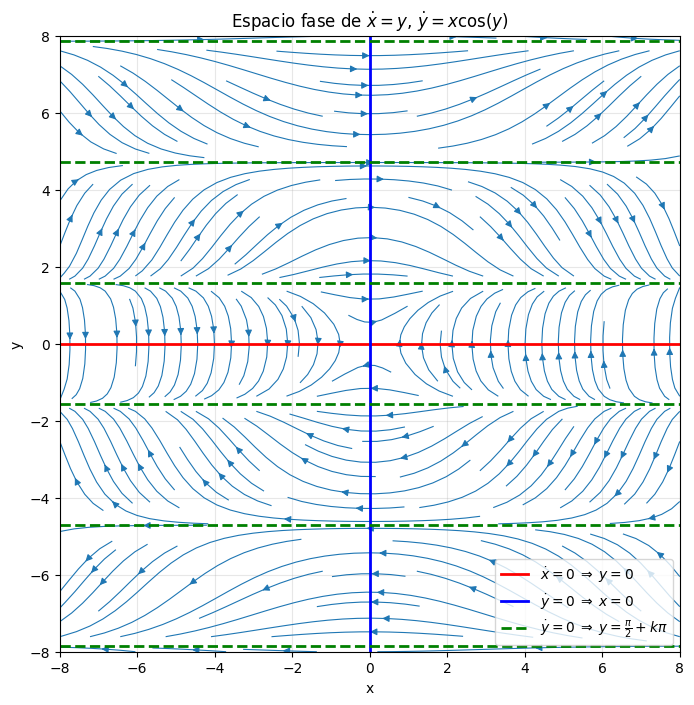

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Sistema:
# x' = y
# y' = x cos(y)
# -----------------------------

# Rango de la ventana
x_min, x_max = -8, 8
y_min, y_max = -8, 8

# Malla
n = 300
x = np.linspace(x_min, x_max, n)
y = np.linspace(y_min, y_max, n)
X, Y = np.meshgrid(x, y)

# Campo vectorial
U = Y              # x' = y
V = X * np.cos(Y)  # y' = x cos(y)

# Normalización opcional para que las flechas no se disparen
M = np.hypot(U, V)
M[M == 0] = 1
U_n = U / M
V_n = V / M

# Figura
plt.figure(figsize=(8, 8))

# Retrato fase
plt.streamplot(X, Y, U_n, V_n, density=1.4, linewidth=0.8, arrowsize=1)

# -----------------------------
# Ceroclinas
# -----------------------------

# 1) Ceroclina de x' = 0  ->  y = 0
plt.axhline(0, color='red', linewidth=2, label=r"$\dot{x}=0 \;\Rightarrow\; y=0$")

# 2) Ceroclina de y' = 0  ->  x cos(y)=0
#    Esto ocurre cuando:
#    a) x = 0
#    b) cos(y) = 0  ->  y = pi/2 + k pi
plt.axvline(0, color='blue', linewidth=2, label=r"$\dot{y}=0 \;\Rightarrow\; x=0$")

# Líneas y = pi/2 + k pi
k_min = int(np.floor((y_min - np.pi/2) / np.pi))
k_max = int(np.ceil((y_max - np.pi/2) / np.pi))

first = True
for k in range(k_min, k_max + 1):
    yk = np.pi/2 + k * np.pi
    if y_min <= yk <= y_max:
        if first:
            plt.axhline(yk, color='green', linestyle='--', linewidth=2,
                        label=r"$\dot{y}=0 \;\Rightarrow\; y=\frac{\pi}{2}+k\pi$")
            first = False
        else:
            plt.axhline(yk, color='green', linestyle='--', linewidth=2)

# Detalles de la gráfica
plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Espacio fase de $\dot{x}=y$, $\dot{y}=x\cos(y)$")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()